<a href="https://colab.research.google.com/github/Thavisha72/Global-Tsunami-prediction/blob/main/Global_Tsunami_Prediction_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Global Tsunami Prediction and EDA

Thavisha Nipun Bandara

Individual Project

In [1]:
# Loading the data set

import pandas as pd

url = "https://raw.githubusercontent.com/Thavisha72/Global-Tsunami-prediction/main/earthquake_data_tsunami.csv"

data = pd.read_csv(url)

In [2]:
print(data.head())
print('-'*50)
print("\nShape:", data.shape)
print('-'*50)
print("\nColomns:", data.columns)
print('-'*50)
print("\nData types:", data.dtypes)

   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  
--------------------------------------------------

Shape: (782, 13)
--------------------------------------------------

Colomns: Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')
--------------------------------------------------

Data types: magnitude    float64

## Data Preprocessing

In [3]:
#handling missing values
null_val= data.isnull().sum()
print(null_val)

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64


In [4]:
# duplicates

print("Duplicates", data.duplicated().sum())

Duplicates 0


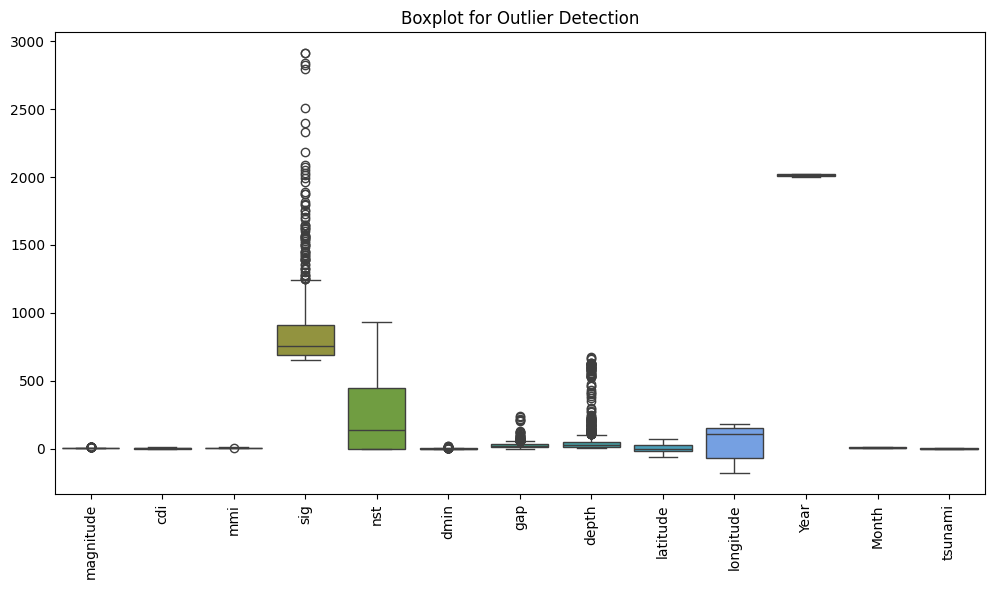

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [6]:
# checking for outliers

import numpy as np

columns = data.select_dtypes(include=np.number).columns

for column in columns:
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  data_new = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

print(data_new.shape)


(782, 13)


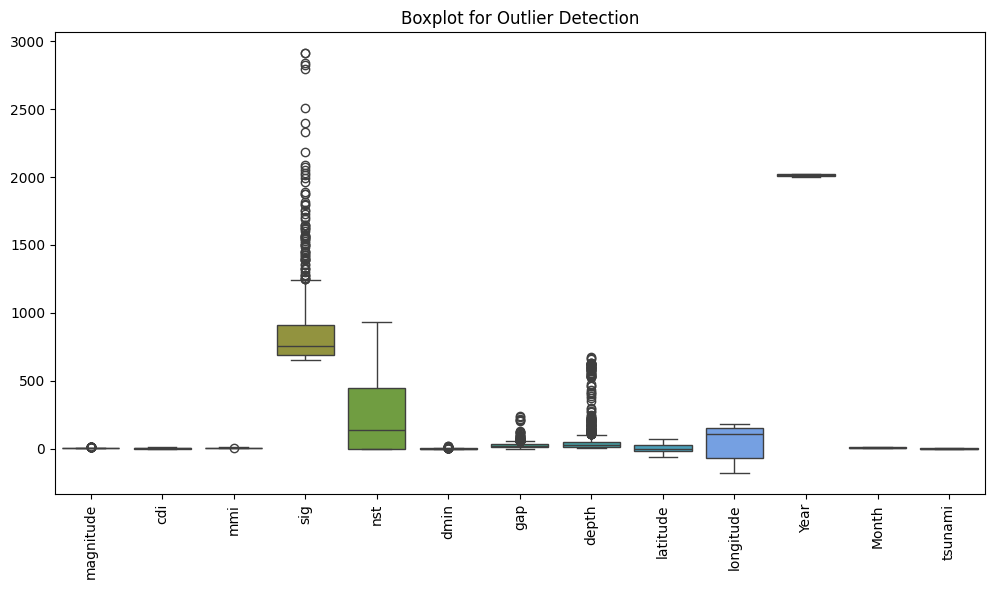

In [7]:
num_cols = data_new.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=data_new[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [8]:
data_new.head()


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


# EDA

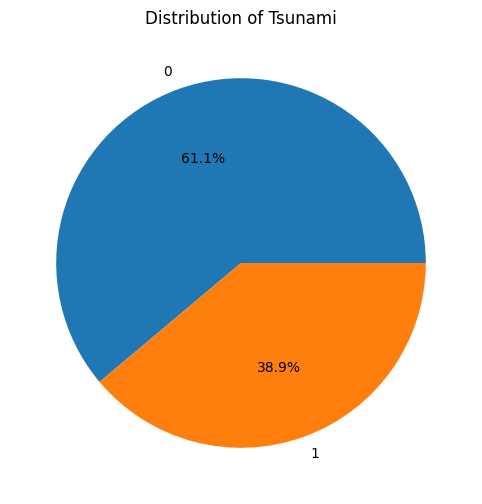

In [20]:
# Tsunami Distribution
import matplotlib.pyplot as plt

tsunami_counts = data_new['tsunami'].value_counts()

plt.figure(figsize=(8,6))
plt.pie(tsunami_counts, labels=tsunami_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Tsunami")
plt.show()

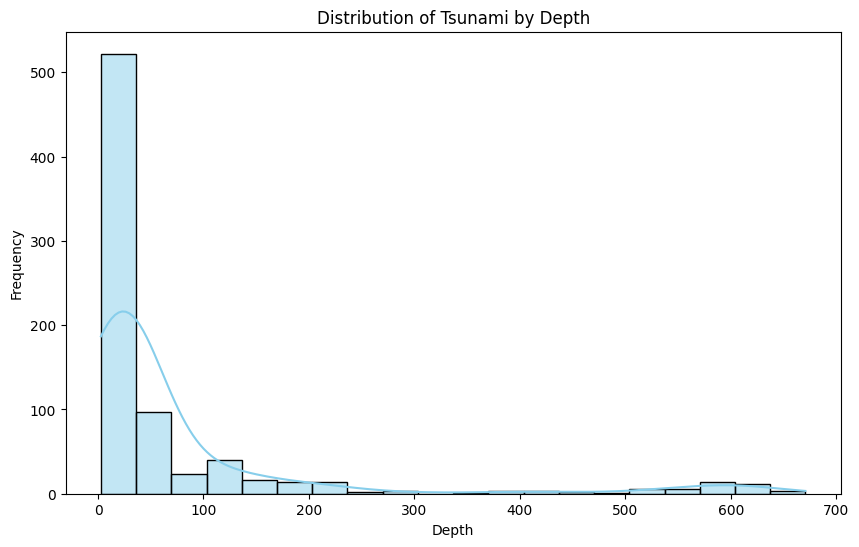

In [21]:
# tsunami distribution by depth

plt.figure(figsize=(10,6))
sns.histplot(data_new['depth'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Tsunami by Depth")
plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.show()

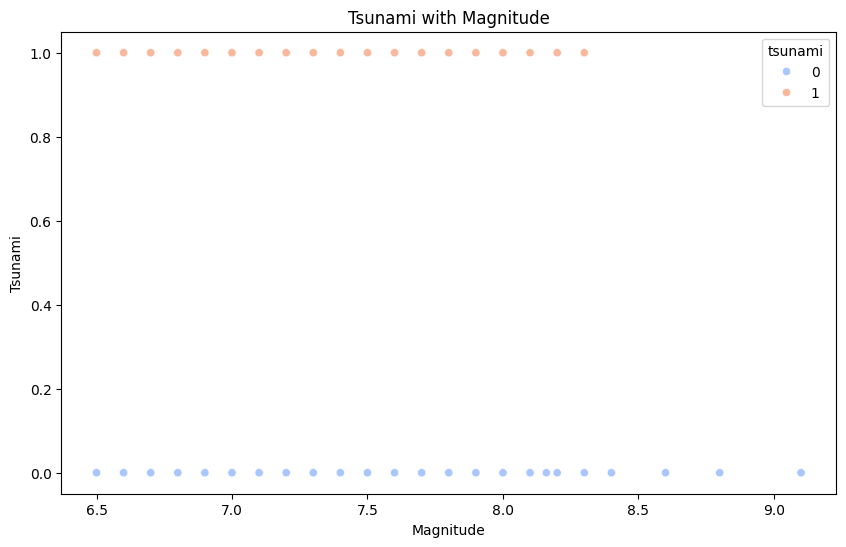

In [22]:
# tsunami with magnitude scatter plot

plt.figure(figsize=(10,6))
sns.scatterplot(data=data_new, x='magnitude', y='tsunami', hue='tsunami', palette='coolwarm')
plt.title("Tsunami with Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Tsunami")
plt.show()

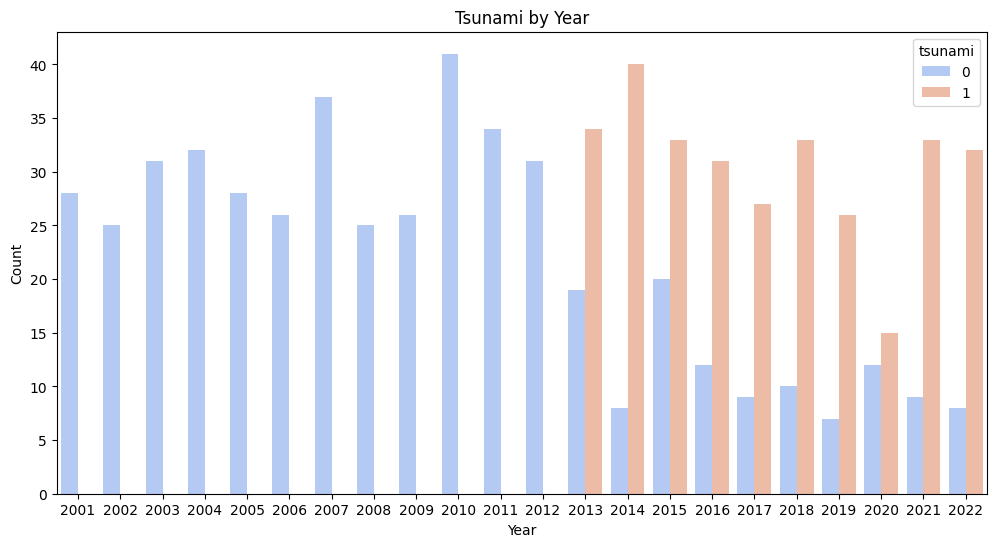

In [25]:
# tsunami by year

plt.figure(figsize=(12,6))
sns.countplot(data=data_new, x='Year', hue='tsunami', palette='coolwarm')
plt.title("Tsunami by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

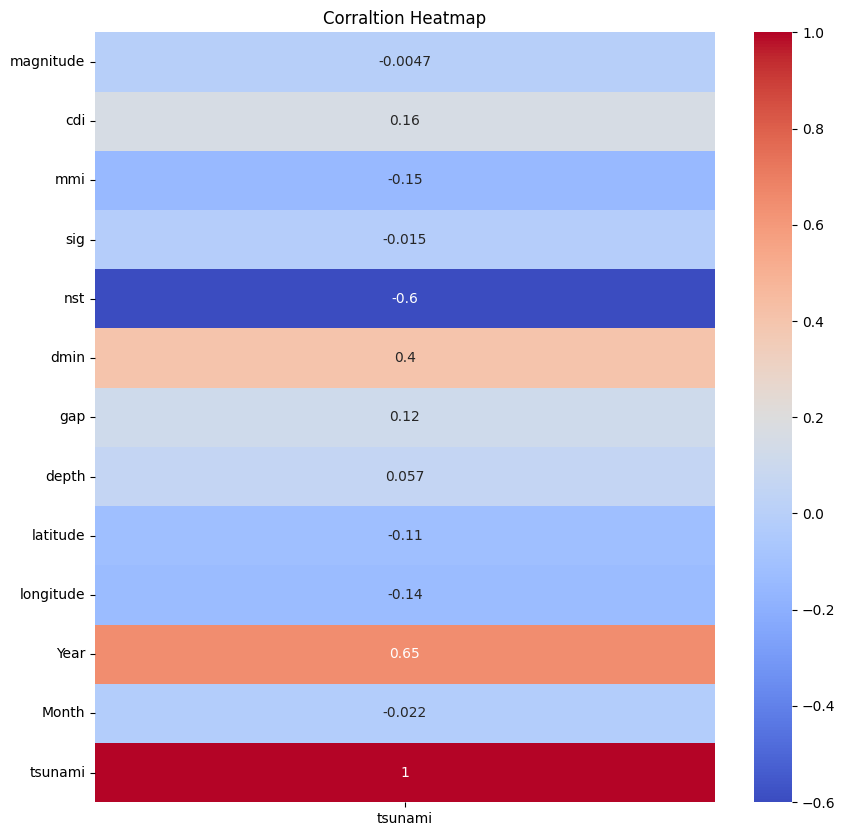

In [9]:
corr = data_new.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr[["tsunami"]], annot=True, cmap='coolwarm')
plt.title("Corraltion Heatmap")
plt.show

In [10]:
# convert numerical values to Categerical Values

labels = {0: 'No Tsunami', 1: 'Tsunami'}
data_new['tsunami'] = data_new['tsunami'].map(labels)

print(data_new.head())


   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month     tsunami  
0  2022     11     Tsunami  
1  2022     11  No Tsunami  
2  2022     11     Tsunami  
3  2022     11     Tsunami  
4  2022     11     Tsunami  


## Training ML models

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

# Revert 'tsunami' column to numerical values (0 and 1) for splitting
data_new['tsunami'] = data_new['tsunami'].map({'No Tsunami': 0, 'Tsunami': 1})

#target
y = data_new['tsunami'].astype(int)

# features
X = data_new.drop("tsunami", axis=1)

# splitting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Comparing Multiple Models

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC # Corrected: SCV to SVC
from sklearn.tree import DecisionTreeClassifier

models_dict = { # Renamed to avoid shadowing
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "SVC": SVC(),
    "DecisionTree": DecisionTreeClassifier()
}

results = [] # Initialize results list

for name, model in models_dict.items(): # Changed loop variable to 'model'
  model.fit(X_train , y_train)
  y_prod = model.predict(X_test)

  results.append({
      'Model': name,
      'Accuracy': accuracy_score(y_test, y_prod) # Changed y_train to y_prod
  })

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Accuracy Visualization

/tmp/ipykernel_5488/1912279607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


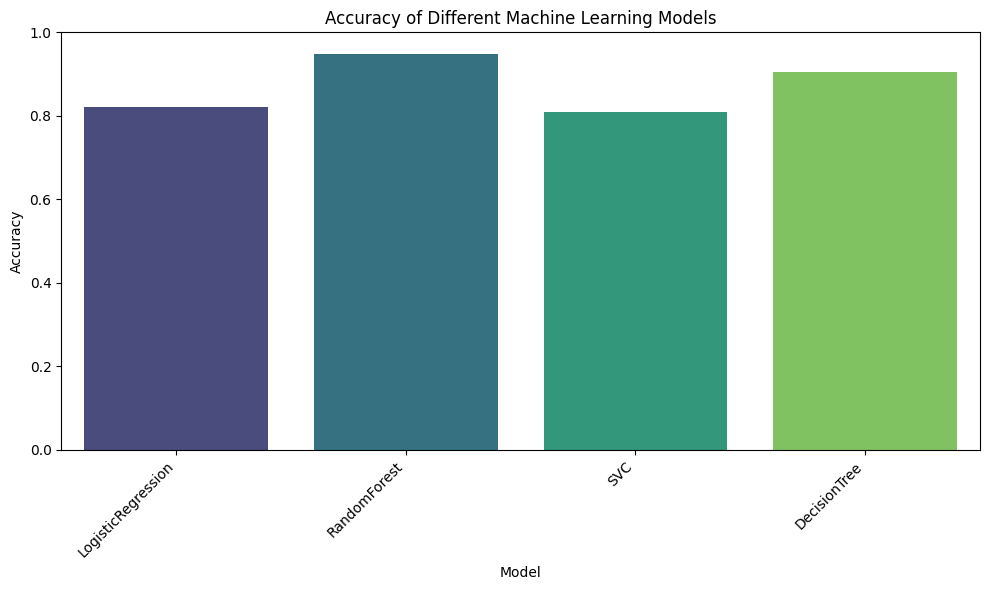

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Accuracy of Different Machine Learning Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Demonstrating Prediction with the Best Model

Now, let's identify the best model and demonstrate how to use it for prediction.

In [17]:
# Find the best model based on accuracy
best_model_name = results_df.loc[results_df['Accuracy'].idxmax()]['Model']
best_model = models_dict[best_model_name]

print(f"The best performing model is: {best_model_name} with an accuracy of {results_df['Accuracy'].max():.4f}\n")

# Make a prediction on a sample from the test set
# For demonstration, let's pick the first 5 samples from X_test
sample_data = X_test.head(5)
predictions = best_model.predict(sample_data)

print("Sample Data for Prediction:")
display(sample_data)

print(f"\nPredictions using {best_model_name}:")
print(predictions)

print("\nActual values for the sample data:")
print(y_test.head(5).values)

The best performing model is: RandomForest with an accuracy of 0.9490

Sample Data for Prediction:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month
395,6.8,0,3,711,131,0.000,18.0,602.2,18.7280,145.2880,2013,5
332,6.9,8,7,1079,0,0.263,51.0,53.0,14.7240,-92.4614,2014,7
25,7.3,9,8,2397,0,2.936,29.0,41.0,37.7015,141.5870,2022,3
693,6.6,0,4,670,728,0.000,18.3,187.1,36.5120,71.0290,2004,4
667,7.2,5,6,802,385,0.000,27.9,39.2,6.9100,92.9580,2004,12



Predictions using RandomForest:
[1 1 1 0 0]

Actual values for the sample data:
[0 1 1 0 0]
